# Myopia Image Classification Training



In [1]:
# %pip install tensorflow matplotlib pillow

In [2]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow version:', tf.__version__)

# Reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)

DATA_DIR = Path('IMAGES')
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 15

if not DATA_DIR.exists():
    raise FileNotFoundError(f'Dataset folder not found: {DATA_DIR.resolve()}')

print('Dataset path:', DATA_DIR.resolve())

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


KeyboardInterrupt: 

Found 124794 files belonging to 2 classes.
Using 99836 files for training.
Found 124794 files belonging to 2 classes.
Using 24958 files for validation.
Classes: ['Myopia_images', 'Normal_images']


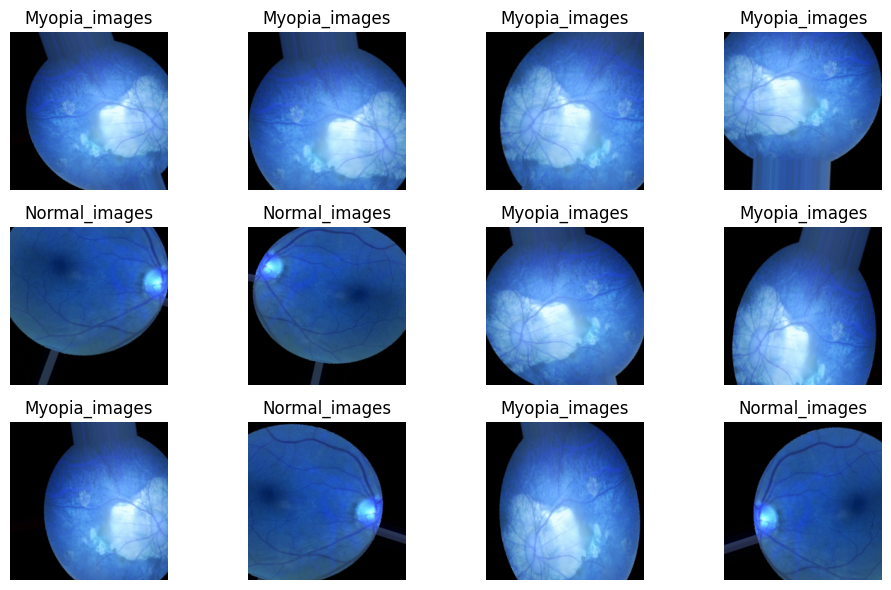

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print('Classes:', class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# Quick sample preview
plt.figure(figsize=(10, 6))
for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='data_augmentation')

base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')],
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

# Optional fine-tuning stage
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')],
)

fine_tune_epochs = 5
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=callbacks,
)

Epoch 1/15
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 2713s 869ms/step - accuracy: 0.9915 - auc: 0.9996 - loss: 0.0243 - val_accuracy: 0.9960 - val_auc: 0.9999 - val_loss: 0.0113 - learning_rate: 0.0010
Epoch 2/15
3120/3120 ━━━━━━━━━━━━━━━━━━━━ 2360s 757ms/step - accuracy: 0.9953 - auc: 0.9998 - loss: 0.0128 - val_accuracy: 0.9971 - val_auc: 0.9998 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 3/15
 763/3120 ━━━━━━━━━━━━━━━━━━━━ 23:59 611ms/step - accuracy: 0.9951 - auc: 0.9998 - loss: 0.0129

In [ ]:
def _merge_history(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history.get(key, []) + h2.history.get(key, [])
    return merged

history_all = _merge_history(history, history_fine)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history_all['loss'], label='train_loss')
plt.plot(history_all['val_loss'], label='val_loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_all['accuracy'], label='train_acc')
plt.plot(history_all['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_all['auc'], label='train_auc')
plt.plot(history_all['val_auc'], label='val_auc')
plt.title('AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate model
val_loss, val_acc, val_auc = model.evaluate(val_ds, verbose=0)
print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_acc:.4f}')
print(f'Validation AUC: {val_auc:.4f}')

# Simple confusion matrix on validation set
all_probs = []
all_labels = []
for batch_images, batch_labels in val_ds:
    probs = model.predict(batch_images, verbose=0).ravel()
    all_probs.extend(probs.tolist())
    all_labels.extend(batch_labels.numpy().tolist())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels).astype(int)
pred_labels = (all_probs >= 0.5).astype(int)

cm = tf.math.confusion_matrix(all_labels, pred_labels, num_classes=2).numpy()
print('Confusion Matrix:')
print(cm)

In [ ]:
# Save the trained model
import os

OUTPUT_DIR = Path('models')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save model in TensorFlow format
model_path = OUTPUT_DIR / 'myopia_image_classifier.keras'
model.save(model_path)
print(f'Model saved to: {model_path.resolve()}')

# Save class names
labels_path = OUTPUT_DIR / 'image_class_labels.json'
with open(labels_path, 'w', encoding='utf-8') as f:
    json.dump(class_names, f, indent=2)
print(f'Class labels saved to: {labels_path.resolve()}')

# Save model metadata
metadata = {
    'model_type': 'MobileNetV2',
    'input_shape': [IMG_HEIGHT, IMG_WIDTH, 3],
    'classes': class_names,
    'validation_accuracy': float(val_acc),
    'validation_loss': float(val_loss),
    'validation_auc': float(val_auc),
}
metadata_path = OUTPUT_DIR / 'model_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata saved to: {metadata_path.resolve()}')

In [ ]:
# Save model and class mapping
OUTPUT_DIR = Path('models')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model_path = OUTPUT_DIR / 'myopia_image_classifier.keras'
labels_path = OUTPUT_DIR / 'myopia_image_labels.json'

model.save(model_path)
with open(labels_path, 'w', encoding='utf-8') as f:
    json.dump(class_names, f, indent=2)

print('Saved model:', model_path.resolve())
print('Saved labels:', labels_path.resolve())

In [ ]:
def predict_image(image_path, threshold=0.5):
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(f'Image not found: {image_path}')

    img = tf.keras.utils.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)

    prob = float(model.predict(arr, verbose=0)[0][0])
    pred_idx = 1 if prob >= threshold else 0
    pred_name = class_names[pred_idx]

    return {
        'image': str(image_path),
        'probability_myopia': prob,
        'predicted_class': pred_name,
        'threshold': threshold,
    }

# Example:
# result = predict_image('IMAGES/Myopia_images/example.jpg')
# print(result)